Enhanced validation plot saved to: C:\Users\24300\Desktop\Ada_S\fig\validation.pdf


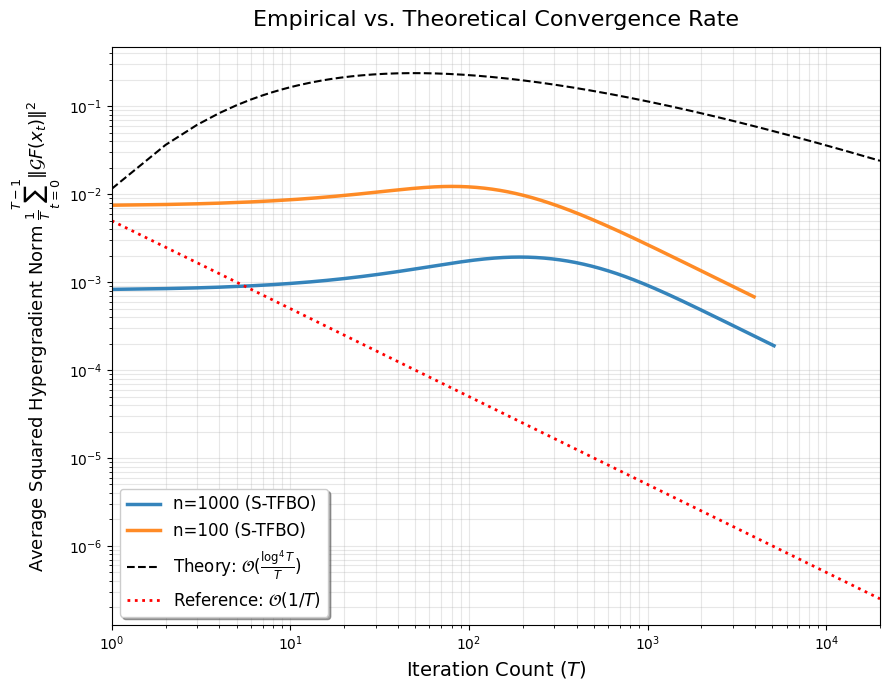

In [1]:
import pickle
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. 路径设置
# ==========================================
file_paths = {
    "n=1000 (S-TFBO)": r"C:\Users\24300\Desktop\Ada_S\results\simple_n1000d50r20_AdaRHD_S_seed7270.pickle",
    "n=100 (S-TFBO)": r"C:\Users\24300\Desktop\Ada_S\results\simple_n100d50r20_AdaRHD_S_seed7270.pickle"
}
save_dir = r"C:\Users\24300\Desktop\Ada_S\fig"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

def load_data(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

# ==========================================
# 2. 绘图配置 (学术风格)
# ==========================================
plt.figure(figsize=(9, 7))
colors = ['#1f77b4', '#ff7f0e'] # 经典学术蓝与橙
T_max = 20000
T = np.arange(1, T_max + 1)

# ==========================================
# 3. 加载并绘制实测曲线
# ==========================================
for i, (label, path) in enumerate(file_paths.items()):
    data = load_data(path)
    hg_norm = np.array(data['hg_norm'])
    # 计算均方超梯度范数的累积平均: (1/T) * sum_{t=0}^{T-1} ||g_t||^2
    running_avg_norm_sq = np.cumsum(hg_norm**2) / (np.arange(len(hg_norm)) + 1)
    
    epochs = np.arange(1, len(running_avg_norm_sq) + 1)
    plt.loglog(epochs, running_avg_norm_sq, label=label, color=colors[i], linewidth=2.5, alpha=0.9)

# ==========================================
# 4. 绘制两条理论参考曲线
# ==========================================
# 理论 1: O(log^4 T / T) - 本文算法的上界
rate_log4 = (np.log(T + 1)**4) / T
# 理论 2: O(1/T) - 理想标准的参考线
rate_inv_t = 1.0 / T

# 对齐常数 C 以便观察包络 (基于 n=1000 数据量级自动缩放)
c_log4 = 0.05 
c_inv_t = 0.005

plt.loglog(T, c_log4 * rate_log4, 'k--', label=r'Theory: $\mathcal{O}(\frac{\log^4 T}{T})$', linewidth=1.5)
plt.loglog(T, c_inv_t * rate_inv_t, 'r:', label=r'Reference: $\mathcal{O}(1/T)$', linewidth=2)

# ==========================================
# 5. 图像细节美化
# ==========================================
plt.title(r'Empirical vs. Theoretical Convergence Rate', fontsize=16, pad=15)
plt.xlabel(r'Iteration Count ($T$)', fontsize=14)
plt.ylabel(r'Average Squared Hypergradient Norm $\frac{1}{T}\sum_{t=0}^{T-1}\|\mathcal{G}F(x_t)\|^2$', fontsize=13)

# 调整网格线，使其在 Log 坐标下更清晰
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend(fontsize=12, loc='best', frameon=True, shadow=True)

# 限制坐标轴范围，使趋势更集中
plt.xlim(1, T_max)

plt.tight_layout()
save_path = os.path.join(save_dir, "validation.pdf")
plt.savefig(save_path, dpi=300)
print(f"Enhanced validation plot saved to: {save_path}")
plt.show()